In [1]:
import numpy as np

def compute_start_indices(size, window_size, stride):
    if size <= window_size:
        return [0]
    else:
        starts = list(range(0, size - window_size + 1, stride))
        if starts[-1] + window_size < size:
            starts.append(size - window_size)
        return starts

def extract_patches(array, window_size=256, overlap=128):
    """
    Extract overlapping patches from a 2D NumPy array.
    
    Parameters:
    - array: Input 2D NumPy array.
    - window_size: Size of the window (patch).
    - overlap: Number of pixels to overlap between patches.
    
    Returns:
    - patches_array: NumPy array of patches with shape (num_patches, window_size, window_size).
    - positions: List of (y, x) positions where each patch was extracted.
    """
    stride = window_size - overlap
    height, width = array.shape
    x_starts = compute_start_indices(width, window_size, stride)
    y_starts = compute_start_indices(height, window_size, stride)
    
    patches = []
    positions = []
    for y in y_starts:
        for x in x_starts:
            patch = array[y:y+window_size, x:x+window_size]
            patches.append(patch)
            positions.append((y, x))
    patches_array = np.stack(patches)
    return patches_array, positions

def reconstruct_from_patches(patches, positions, array_shape, window_size=256, overlap=128):
    """
    Reconstruct the original array from patches, applying logical AND in overlapping regions.
    
    Parameters:
    - patches: NumPy array of patches with shape (num_patches, window_size, window_size).
    - positions: List of (y, x) positions where each patch should be placed.
    - array_shape: Shape of the original array (height, width).
    - window_size: Size of the window (patch).
    - overlap: Number of pixels that overlap between patches.
    
    Returns:
    - output_array: Reconstructed 2D NumPy array.
    """
    # Initialize the output array to all True values
    output_array = np.ones(array_shape, dtype=bool)
    count_array = np.zeros(array_shape, dtype=int)
    
    for idx, (y, x) in enumerate(positions):
        patch = patches[idx]
        # Create a mask for the current patch
        patch_mask = np.zeros(array_shape, dtype=bool)
        patch_mask[y:y+window_size, x:x+window_size] = True
        
        # Update the count of overlaps
        count_array[y:y+window_size, x:x+window_size] += 1
        
        # Apply logical AND operation
        output_array[y:y+window_size, x:x+window_size] = np.logical_and(
            output_array[y:y+window_size, x:x+window_size], patch
        )
    
    # Optional: You might want to consider only areas where the overlap count is more than 1
    # For example, setting areas with no overlap to the original detection values
    # This can be customized based on your specific requirements
    
    return output_array

In [2]:
# Example input array
input_array = np.random.rand(2048, 511)

# Extract patches
patches, positions = extract_patches(input_array, window_size=256, overlap=128)

# Simulate model detections (binary detection masks)
# For demonstration, let's say detections are where the value is greater than 0.5
detections = (patches > 0.5)

# Reconstruct the detection masks back into the original array size
reconstructed_detections = reconstruct_from_patches(
    detections, positions, input_array.shape, window_size=256, overlap=128
)

In [38]:
detections.shape

(45, 256, 256)

In [39]:
patches.shape

(45, 256, 256)

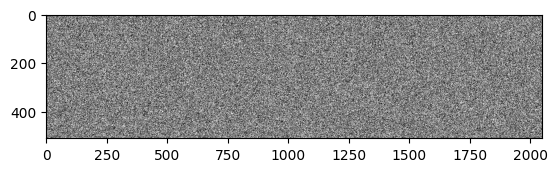

In [3]:
import matplotlib.pyplot as plt
plt.imshow(reconstructed_detections.T, cmap='gray')

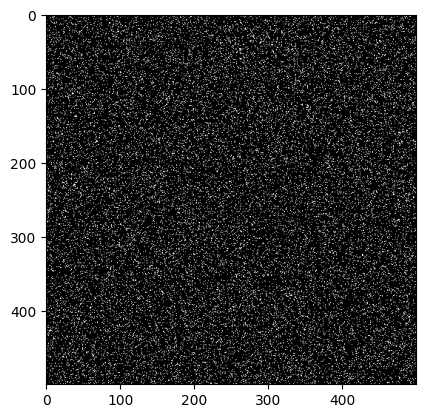

In [19]:
plt.imshow(input_array>.9, cmap='gray')

In [4]:
import numpy as np

def compute_start_indices(size, patch_size, stride):
    if size <= patch_size:
        return [0]
    else:
        starts = list(range(0, size - patch_size + 1, stride))
        if starts[-1] + patch_size < size:
            starts.append(size - patch_size)
        return starts

def extract_patches_with_context(array, patch_size=192, context_size=256):
    """
    Extract patches from a 2D NumPy array and expand each patch with extra context.

    Parameters:
    - array: Input 2D NumPy array.
    - patch_size: Size of the central patch (192x192).
    - context_size: Size of the patch including context (256x256).

    Returns:
    - patches_array: NumPy array of patches with shape (num_patches, context_size, context_size).
    - positions: List of (y, x) positions where each patch was extracted.
    """
    height, width = array.shape
    stride = patch_size  # Non-overlapping patches
    x_starts = compute_start_indices(width, patch_size, stride)
    y_starts = compute_start_indices(height, patch_size, stride)
    
    patches = []
    positions = []
    for y in y_starts:
        for x in x_starts:
            # Coordinates for the central patch
            y_center = y + patch_size // 2
            x_center = x + patch_size // 2

            # Coordinates for the context patch
            y_start = y_center - context_size // 2
            y_end = y_start + context_size
            x_start = x_center - context_size // 2
            x_end = x_start + context_size

            # Initialize the context patch
            context_patch = np.zeros((context_size, context_size), dtype=array.dtype)

            # Calculate the overlap between the array and the context patch
            array_y_start = max(0, y_start)
            array_y_end = min(height, y_end)
            array_x_start = max(0, x_start)
            array_x_end = min(width, x_end)

            context_y_start = array_y_start - y_start
            context_y_end = context_y_start + (array_y_end - array_y_start)
            context_x_start = array_x_start - x_start
            context_x_end = context_x_start + (array_x_end - array_x_start)

            # Copy the data from the array to the context patch
            context_patch[context_y_start:context_y_end, context_x_start:context_x_end] = \
                array[array_y_start:array_y_end, array_x_start:array_x_end]

            # Fill the missing context with random patches
            missing_mask = context_patch == 0
            num_missing = np.sum(missing_mask)
            if num_missing > 0:
                # Sample random positions from the array to fill the missing context
                random_indices = np.random.randint(0, height * width, size=num_missing)
                random_values = array.flatten()[random_indices]
                context_patch[missing_mask] = random_values

            patches.append(context_patch)
            positions.append((y, x))
    patches_array = np.stack(patches)
    return patches_array, positions

def crop_patches(patches, crop_size=192):
    """
    Crop the central region from each patch.

    Parameters:
    - patches: NumPy array of patches with shape (num_patches, context_size, context_size).
    - crop_size: Size of the central crop (192x192).

    Returns:
    - cropped_patches: NumPy array of cropped patches with shape (num_patches, crop_size, crop_size).
    """
    context_size = patches.shape[1]
    start = (context_size - crop_size) // 2
    end = start + crop_size
    cropped_patches = patches[:, start:end, start:end]
    return cropped_patches

def reconstruct_from_patches(patches, positions, array_shape, patch_size=192):
    """
    Reconstruct the original array from cropped patches.

    Parameters:
    - patches: NumPy array of cropped patches with shape (num_patches, patch_size, patch_size).
    - positions: List of (y, x) positions where each patch should be placed.
    - array_shape: Shape of the original array (height, width).
    - patch_size: Size of the central patch (192x192).

    Returns:
    - output_array: Reconstructed 2D NumPy array.
    """
    output_array = np.zeros(array_shape, dtype=patches.dtype)
    for idx, (y, x) in enumerate(positions):
        output_array[y:y+patch_size, x:x+patch_size] = patches[idx]
    return output_array

In [20]:
# Example input array
input_array = np.random.rand(1000, 500)

# Extract patches with context
patches_with_context, positions = extract_patches_with_context(input_array)

# Simulate model processing on the patches
# For demonstration, let's invert the patches
processed_patches = patches_with_context >0.5  # Replace with your model's output

# Crop back to 192x192
cropped_patches = crop_patches(patches_with_context)

cropped_patches = cropped_patches > 0.9
# Reconstruct the array
reconstructed_array = reconstruct_from_patches(cropped_patches, positions, input_array.shape)

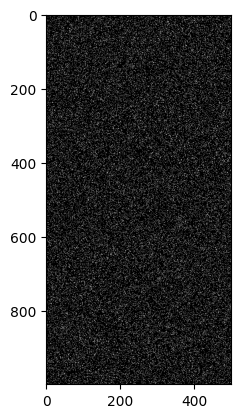

In [21]:
import matplotlib.pyplot as plt

plt.imshow(reconstructed_array, cmap='gray')

In [16]:
processed_patches.shape

(18, 256, 256)

In [17]:
cropped_patches.shape

(18, 192, 192)